## Initial setup

In [1]:
# Import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import data
df = pd.read_csv('jupiter_JPL_table.txt', sep='\t')  # tab delimiter is denoted as '\t'

### Define boolean arrays for filtering groups ###
# progrades
Himalia = (df['a'] >= 1e7) & (df['a'] <= 1.25e7) & (df['i'] >= 27) & (df['i'] <= 30)
Carpo = (df['a'] >= 1.5e7) & (df['a'] <= 1.8e7) & (df['i'] >= 40) & (df['i'] <= 60)
Themisto = (df['a'] >= 5e6) & (df['a'] <= 1e7) & (df['i'] <= 60)
Valetudo = (df['a'] >= 1.5e7) & (df['a'] <= 2.5e7) & (df['i'] >= 30) & (df['i'] <= 45)
# retrogrades
Carme = (df['a'] >= 2.25e7) & (df['i'] >= 160)
Pasiphae = (df['a'] >= 2.2e7) & (df['i'] >= 130) & (df['i'] <= 160)
Ananke = (df['a'] >= 1.75e7) & (df['a'] <= 2.2e7) & (df['i'] >= 140) & (df['i'] <= 160)
# everything else
ungrouped = ~Himalia & ~Carpo & ~Carme & ~Pasiphae & ~Ananke

In [2]:
print(df)

      Satellite   Code           a      e      ω      M      i   node  \
0       Himalia    506  11439000.0  0.160  321.1   78.3   28.4   64.2   
1         Elara    507  11710700.0  0.212  129.9  346.9   27.8  112.8   
2      Pasiphae    508  23463200.0  0.412  172.8  279.3  148.3  315.7   
3        Sinope    509  23679300.0  0.262  354.3  157.4  157.3  308.0   
4      Lysithea    510  11699100.0  0.117   48.3  328.5   27.7    9.2   
..          ...    ...         ...    ...    ...    ...    ...    ...   
102  S2017_J_16  55540  23007800.0  0.268  178.6  148.8  164.7    4.7   
103  S2017_J_17  55541  11776100.0  0.164   95.0  244.5   29.0  322.4   
104  S2017_J_18  55542  22923800.0  0.254  238.8   40.6  164.9   39.9   
105   S2021_J_7  55543  23305900.0  0.253   13.3  293.4  149.4  286.5   
106   S2021_J_8  55544  20978900.0  0.243   34.6   85.0  147.1  132.0   

            P  Papsis  Pnode  Ref.  
0    249.9090   187.4  297.1    47  
1    258.8861   173.0  270.9    47  
2    734.421

## Addtional setup: Prepare new dataframe with H and D

In [6]:
import pandas as pd
import re


def clean_satellite_name(raw_name):
    """
    Extracts and cleans the satellite name by:
    - Removing 'Jupiter + Roman numeral'
    - Using the name inside parentheses when available
    - Removing slashes
    - Replacing spaces with underscores

    (This function was generated by ChatGPT.)
    """
    raw_name = raw_name.strip()

    # Case 1: Use the name inside parentheses (e.g., Himalia)
    match = re.search(r"\((.*?)\)", raw_name)
    if match:
        name = match.group(1)
    else:
        # Case 2: Remove "Jupiter <Roman Numeral>"
        name = re.sub(r"^Jupiter\s+[IVXLCDM]+\s*", "", raw_name).strip()

    # Remove slashes
    name = name.replace("/", "")

    # Replace spaces with underscores
    name = name.replace(" ", "_")

    # Remove unwanted characters except letters, numbers, and underscores
    name = re.sub(r"[^A-Za-z0-9_]", "", name)

    # Remove duplicate underscores
    name = re.sub(r"_+", "_", name)

    # Remove leading/trailing underscores
    return name.strip("_")


def MPC_convert(file_path):
    """
    Extracts satellite names and H values from the text file
    and returns them as a pandas DataFrame.

    (This function was generated by ChatGPT.)
    """
    satellite_names = []
    h_values = []
    current_satellite = None

    # Patterns to identify satellite names and H values
    satellite_pattern = re.compile(
        r"^(Jupiter\s+[A-Z0-9IVXLCDM]+(?:\s*\(.*?\))?|S/\d{4}\s+J\s+\d+)",
        re.IGNORECASE
    )
    h_pattern = re.compile(r"\bH\s+([0-9]+(?:\.[0-9]+)?)")

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            # Detect satellite name lines
            sat_match = satellite_pattern.match(line)
            if sat_match:
                raw_name = sat_match.group(0)
                current_satellite = clean_satellite_name(raw_name)
                continue

            # Detect H values
            h_match = h_pattern.search(line)
            if h_match and current_satellite:
                satellite_names.append(current_satellite)
                h_values.append(float(h_match.group(1)))
                current_satellite = None

    # Create DataFrame
    df = pd.DataFrame({
        "Satellite": satellite_names,
        "H": h_values
    })

    return df

In [7]:
# Import MPC data; only read name and H
file_path = "jupiter_MPC_table.txt"
df_MPC = MPC_convert(file_path)

# Display results
# print(df_MPC.iloc[[10, 49]])  # in JPL, "Megaclite" and "Philophrosyne" are spelled wrong

# Merge dataframes based on matching values in column
matches = df['Satellite'].isin(df_MPC['Satellite'])
print(matches[matches == False])  # make sure ALL names match with no "False" match flags

# Merge
DF = df.merge(df_MPC, on='Satellite')
print(f"Length of final merged dataframe:  len(DF) = {len(DF)}")  # Make sure the final merged DF length is 107
print(f"Does the final merged dataframe equal the original JPL dataframe length?\n{len(DF) == len(df)}")  # Make sure the final merged DF length is 107
# print(DF)

Series([], Name: Satellite, dtype: bool)
Length of final merged dataframe:  len(DF) = 107
Does the final merged dataframe equal the original JPL dataframe length?
True


In [8]:
def H_to_D(H, albedo=0.04):
    '''
    Function that converts absolute magnitude (H) and albedo into diameter (in km).

    INPUT:
     - H
     - albedo (set to 0.04 by default)
    OUTPUT:
     - diameter (km)
    '''
    D = (1329/np.sqrt(albedo)) * 10**(-0.2*H)
    return D

# Add two new columns: diameter (km) and inverse diameter (1/D)
DF['Diameter (km)'] = H_to_D(DF['H'], albedo=0.04)
DF['1/D'] = 1/DF['Diameter (km)']

print(DF)

      Satellite   Code           a      e      ω      M      i   node  \
0       Himalia    506  11439000.0  0.160  321.1   78.3   28.4   64.2   
1         Elara    507  11710700.0  0.212  129.9  346.9   27.8  112.8   
2      Pasiphae    508  23463200.0  0.412  172.8  279.3  148.3  315.7   
3        Sinope    509  23679300.0  0.262  354.3  157.4  157.3  308.0   
4      Lysithea    510  11699100.0  0.117   48.3  328.5   27.7    9.2   
..          ...    ...         ...    ...    ...    ...    ...    ...   
102  S2017_J_16  55540  23007800.0  0.268  178.6  148.8  164.7    4.7   
103  S2017_J_17  55541  11776100.0  0.164   95.0  244.5   29.0  322.4   
104  S2017_J_18  55542  22923800.0  0.254  238.8   40.6  164.9   39.9   
105   S2021_J_7  55543  23305900.0  0.253   13.3  293.4  149.4  286.5   
106   S2021_J_8  55544  20978900.0  0.243   34.6   85.0  147.1  132.0   

            P  Papsis  Pnode  Ref.      H  Diameter (km)       1/D  
0    249.9090   187.4  297.1    47   7.90     174.7813

# Polar plot for orbital elements

In [13]:
# Add new column for reduced semimajor axis (e6km)
DF['a_e6km'] = DF['a']/1e6

# DEFINE JUPITER HILL RADIUS (in km)
AU = 149597870700 # in meters
a_Jup = 5.2038 * AU
e_Jup = 0.0489
M_jup = 1.89813 * 10**27 # in kg
M_sun = 1.988416 * 10**30 # in kg
Hill_radius = a_Jup*(1-e_Jup)*(M_jup/(3*(M_sun+M_jup)))**(1/3) / 1000
Hill_radius_e6km = Hill_radius / 1e6

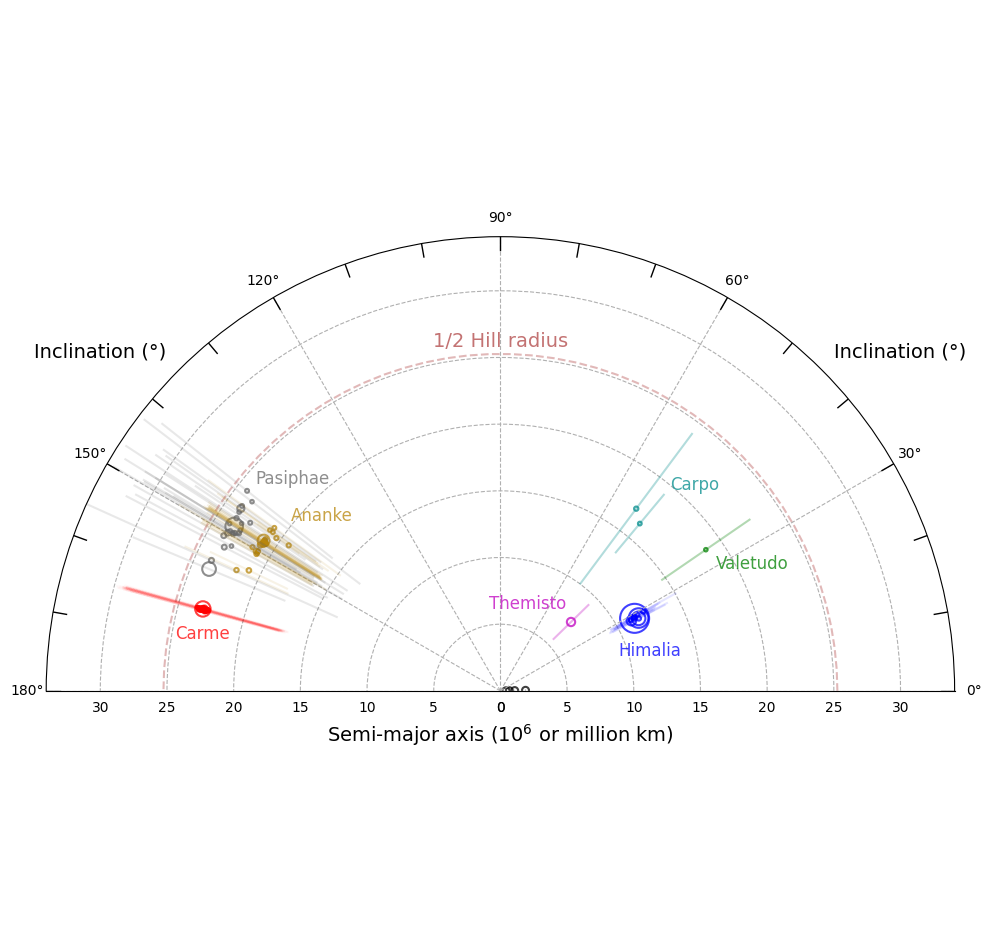

In [16]:
# global settings
size = 10  # figure size
alpha = 0.75  # point opacity
err_alpha = 0.1  # errorbar opacity
sf = 10  # scale factor
m = '.'  # marker style
fill = 'None'  # marker face (fill) color
lw = 1.5  # marker edge line width

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(size,size))

### PLOT POINTS ###
reg_a = np.array([421800, 671100, 1070400, 1882700])/1e6
reg_i = np.deg2rad([1.303,1.303,1.303,1.303])
ax.scatter(reg_i, reg_a,
            s=sf*10, marker=m,
            facecolors=fill, edgecolors='k', lw=lw,
            alpha=alpha, label='Regular moons')
ax.errorbar(reg_i, reg_a,
            yerr = reg_a*0.005,
            fmt = 'none', alpha = 1,
            c='k')
# progrades
ax.scatter(np.deg2rad(DF['i'][Himalia]), DF['a_e6km'][Himalia],
            s=sf*DF['Diameter (km)'][Himalia], marker=m,
            facecolors=fill, edgecolors='b', lw=lw,
            alpha=alpha, label='Himalia')
ax.scatter(np.deg2rad(DF['i'][Carpo]), DF['a_e6km'][Carpo],
            s=sf*DF['Diameter (km)'][Carpo], marker=m,
            facecolors=fill, edgecolors='darkcyan', lw=lw,
            alpha=alpha, label='Carpo')
ax.scatter(np.deg2rad(DF['i'][Themisto]), DF['a_e6km'][Themisto], 
            s=sf*DF['Diameter (km)'][Themisto], marker=m,
            facecolors=fill, edgecolors='m', lw=lw,
            alpha=alpha, label='Themisto')
ax.scatter(np.deg2rad(DF['i'][Valetudo]), DF['a_e6km'][Valetudo], 
            s=sf*DF['Diameter (km)'][Valetudo], marker=m,
            facecolors=fill, edgecolors='g', lw=lw,
            alpha=alpha, label='Valetudo')
# retrogrades
ax.scatter(np.deg2rad(DF['i'][Carme]), DF['a_e6km'][Carme], 
            s=sf*DF['Diameter (km)'][Carme], marker=m,
            facecolors=fill, edgecolors='r', lw=lw,
            alpha=alpha, label='Carme')
ax.scatter(np.deg2rad(DF['i'][Pasiphae]), DF['a_e6km'][Pasiphae],
            s=sf*DF['Diameter (km)'][Pasiphae], marker=m,
            facecolors=fill, edgecolors='dimgray', lw=lw,
            alpha=alpha, label='Pasiphae')
ax.scatter(np.deg2rad(DF['i'][Ananke]), DF['a_e6km'][Ananke],
            s=sf*DF['Diameter (km)'][Ananke], marker=m,
            facecolors=fill, edgecolors='darkgoldenrod', lw=lw,
            alpha=alpha, label='Ananke')

### PLOT ECCENTRICITY ###
# progrades
ax.errorbar(np.deg2rad(DF['i'][Himalia]), DF['a_e6km'][Himalia],
            yerr = DF['a_e6km'][Himalia]*DF['e'][Himalia],
            fmt = 'none', alpha = err_alpha,
            c='b')
ax.errorbar(np.deg2rad(DF['i'][Carpo]), DF['a_e6km'][Carpo],
            yerr = DF['a_e6km'][Carpo]*DF['e'][Carpo],
            fmt = 'none', alpha = 0.3,
            c='darkcyan')
ax.errorbar(np.deg2rad(DF['i'][Themisto]), DF['a_e6km'][Themisto],
            yerr = DF['a_e6km'][Themisto]*DF['e'][Themisto],
            fmt = 'none', alpha = 0.3,
            c='m')
ax.errorbar(np.deg2rad(DF['i'][Valetudo]), DF['a_e6km'][Valetudo],
            yerr = DF['a_e6km'][Valetudo]*DF['e'][Valetudo],
            fmt = 'none', alpha = 0.3,
            c='g')
# retrogrades
ax.errorbar(np.deg2rad(DF['i'][Carme]), DF['a_e6km'][Carme],
            yerr = DF['a_e6km'][Carme]*DF['e'][Carme],
            fmt = 'none', alpha = err_alpha*0.25,
            c='r')
ax.errorbar(np.deg2rad(DF['i'][Pasiphae]), DF['a_e6km'][Pasiphae],
            yerr = DF['a_e6km'][Pasiphae]*DF['e'][Pasiphae],
            fmt = 'none', alpha = err_alpha*1.5,
            c='dimgray')
ax.errorbar(np.deg2rad(DF['i'][Ananke]), DF['a_e6km'][Ananke],
            yerr = DF['a_e6km'][Ananke]*DF['e'][Ananke],
            fmt = 'none', alpha = err_alpha,
            c='darkgoldenrod')


ax.set_rlim([0, 0.95*ax.get_rmax()])  # Fix the plot radius
#ax.set_rticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])  # Define radial ticks
#ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
ax.grid(True, linestyle='--', zorder=-10)


### Angle minor ticks ###
angletick = [ax.get_rmax()*1.05, ax.get_rmax() * 0.97]  # from outside the plot to slightyly interior to the border
# Iterate the points between 0 to 360 with step=10
for t in np.deg2rad(np.arange(0, 360, 10)):
    ax.plot([t, t], angletick, lw=1, color="black")

# Set angle bounds for plot
ax.set_thetamin(0)
ax.set_thetamax(180)

# Make radius axis labels on both left and right sides
ax.yaxis.set_tick_params(labelright=True)


# Add text labels for moon groups on top of the plot
# plt.text uses (angle [radians], radius)
## Progrades
plt.text(np.deg2rad(13.5), 11.5, "Himalia", rotation=0, fontsize=12, ha='center', color='b', alpha=alpha)
plt.text(np.deg2rad(26), 21, "Valetudo", rotation=0, fontsize=12, ha='center', color='g', alpha=alpha)
plt.text(np.deg2rad(46), 21, "Carpo", rotation=0, fontsize=12, ha='center', color='darkcyan', alpha=alpha)
plt.text(np.deg2rad(72), 6.5, "Themisto", rotation=0, fontsize=12, ha='center', color='m', alpha=alpha)
## Retrogrades
plt.text(np.deg2rad(170), 22.7, "Carme", rotation=0, fontsize=12, ha='center', color='r', alpha=alpha)
plt.text(np.deg2rad(135), 22, "Pasiphae", rotation=0, fontsize=12, ha='center', color='dimgrey', alpha=alpha)
plt.text(np.deg2rad(136.5), 18.5, "Ananke", rotation=0, fontsize=12, ha='center', color='darkgoldenrod', alpha=alpha)
'''
## Progrades (tilted text)
plt.text(np.deg2rad(13.5), 11.5, "Himalia", rotation=13.5, fontsize=12, ha='center', color='b', alpha=alpha)
plt.text(np.deg2rad(34), 17.5, "Valetudo", rotation=34, fontsize=12, ha='center', color='g', alpha=alpha)
plt.text(np.deg2rad(47), 21, "Carpo", rotation=47, fontsize=12, ha='center', color='darkcyan', alpha=alpha)
plt.text(np.deg2rad(46), 4.5, "Themisto", rotation=46, fontsize=12, ha='center', color='m', alpha=alpha)
## Retrogrades (tilted text)
plt.text(np.deg2rad(170.5), 22.7, "Carme", rotation=170.5-180, fontsize=12, ha='center', color='r', alpha=alpha)
plt.text(np.deg2rad(143), 27.3, "Pasiphae", rotation=143-180, fontsize=12, ha='center', color='dimgrey', alpha=alpha)
plt.text(np.deg2rad(143), 19, "Ananke", rotation=143-180, fontsize=12, ha='center', color='darkgoldenrod', alpha=alpha)
'''


# label axes and title
#ax.set_xlabel("Semi-major axis (Jupiter Hill radii)", rotation=0, size=14, labelpad=-170)
ax.set_xlabel(r"Semi-major axis ($10^6$ or million km)", rotation=0, size=14, loc='center', labelpad=-170*size/12)
plt.text(45*(np.pi/180), 1.04*ax.get_rmax(), "Inclination (°)", fontsize=14, ha='left', color='black')
plt.text(135*(np.pi/180), 1.04*ax.get_rmax(), "Inclination (°)", fontsize=14, ha='right', color='black')

# Label half Hill radii
ax.plot(np.linspace(0, np.pi), np.ones_like(np.linspace(0, np.pi))*(Hill_radius_e6km/2),
        ls='--', c='brown', alpha=0.33, zorder=-10)
# plt.text uses (angle [radians], radius)
plt.text(np.pi/2, 1.01*Hill_radius_e6km/2, r"1/2 Hill radius",
         fontsize=14, ha='center', va='bottom', color='brown', alpha=0.66)

plt.tight_layout()
plt.savefig("Jupiter_irregular_moons_polar_plot.svg", dpi=300, bbox_inches='tight')
plt.show()